# Block Activation Analysis

This notebook is the representation-geometry entry point of the thesis experiments. It analyzes one frozen SmolLM2 MLP without modifying the model. The default target is zero-based layer 11.

The historical MVP motivates this study, but its archived results are not mixed with the measurements produced here.

## Capture convention and interpretation boundary

- x: input to the complete MLP module after the preceding normalization.
- z: input to down_proj, i.e. the post-gating intermediate activation.
- y: MLP branch output before residual addition.

PCA is used as a reconstruction oracle. It does not create a deployable narrow SwiGLU because the original full-width gated state z must still be computed.

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys

def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from mlp_replacement.analysis import (
    coordinate_orders,
    covariance_eigendecomposition,
    evaluate_reconstruction,
    summarize_activation_spectrum,
)
from mlp_replacement.capture import collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.runlog import environment_record, json_value

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
TARGET_LAYER = 11
PCA_RANKS = (64, 128, 256, 512, 1024, 2048, 4096)

In [3]:
SEED = 21
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_PATH = PROJECT_ROOT / 'data' / 'results' / 'notebook-block-study' / f'activation-layer-{TARGET_LAYER}.json'

In [5]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device=DEVICE,
    dtype='auto',
)
data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=1,
    num_test_batches=0,
    seed=SEED,
)
torch.manual_seed(SEED)
print({'target_layer': TARGET_LAYER, 'device': DEVICE, 'output': str(OUTPUT_PATH)})

{'target_layer': 11, 'device': 'cuda', 'output': '/home/sgulas/thesis/development/data/results/notebook-block-study/activation-layer-11.json'}


In [6]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
loaders = build_data_loaders(tokenizer, data_config, include_recovery=False)
block = get_mlp_block(model, TARGET_LAYER)
down_path = f'{block.path}.down_proj'
down_projection = model.get_submodule(down_path)
print({
    'device': str(device),
    'model_revision': getattr(model.config, '_commit_hash', None),
    'mlp_path': block.path,
    'down_path': down_path,
})

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 5930.15it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


{'device': 'cuda:0', 'model_revision': 'effd688a12921b4cc83e3312b6feb579f70f9c71', 'mlp_path': 'model.layers.11.mlp', 'down_path': 'model.layers.11.mlp.down_proj'}


In [7]:
capture_kwargs = dict(device=device, storage_device='cpu', storage_dtype=torch.float32)
train_xy = collect_module_io(
    model, block.path, loaders.calibration, data_config.num_calibration_batches, **capture_kwargs
)
train_zy = collect_module_io(
    model, down_path, loaders.calibration, data_config.num_calibration_batches, **capture_kwargs
)
validation_xy = collect_module_io(
    model, block.path, loaders.operator_validation, data_config.num_operator_validation_batches, **capture_kwargs
)
validation_zy = collect_module_io(
    model, down_path, loaders.operator_validation, data_config.num_operator_validation_batches, **capture_kwargs
)

train_activations = {'x': train_xy.inputs, 'z': train_zy.inputs, 'y': train_xy.targets}
validation_activations = {
    'x': validation_xy.inputs,
    'z': validation_zy.inputs,
    'y': validation_xy.targets,
}

In [8]:
pd.DataFrame([
    {'name': name, 'split': split, 'tokens': values.shape[0], 'dimension': values.shape[1]}
    for split, mapping in [('calibration', train_activations), ('validation', validation_activations)]
    for name, values in mapping.items()
])

,name,split,tokens,dimension
0,x,calibration,12288,2048
1,z,calibration,12288,8192
2,y,calibration,12288,2048
3,x,validation,6144,2048
4,z,validation,6144,8192
5,y,validation,6144,2048


In [9]:
def activation_summary(name, values):
    values = values.float()
    norms = values.norm(dim=-1)
    mean_energy = values.mean(dim=0).square().sum()
    second_moment = values.square().sum(dim=-1).mean()
    return {
        'activation': name,
        'tokens': values.shape[0],
        'dimension': values.shape[1],
        'mean': float(values.mean()),
        'std': float(values.std()),
        'mean_norm': float(norms.mean()),
        'p50_norm': float(norms.median()),
        'p95_norm': float(torch.quantile(norms, 0.95)),
        'mean_energy_fraction': float(mean_energy / second_moment),
    }

def binned_distribution(values, bins=100, max_samples=100_000):
    flat = values.flatten().float()
    sampled = flat[::max(1, flat.numel() // max_samples)]
    counts, edges = torch.histogram(sampled, bins=bins, density=True)
    return [
        {'left': float(edges[index]), 'right': float(edges[index + 1]), 'density': float(counts[index])}
        for index in range(counts.numel())
    ]

def binned_norms(values, bins=80):
    counts, edges = torch.histogram(values.float().norm(dim=-1), bins=bins, density=True)
    return [
        {'left': float(edges[index]), 'right': float(edges[index + 1]), 'density': float(counts[index])}
        for index in range(counts.numel())
    ]

descriptive_df = pd.DataFrame([
    activation_summary(name, values) for name, values in train_activations.items()
])
histogram_data = {
    name: {'values': binned_distribution(values), 'norms': binned_norms(values)}
    for name, values in train_activations.items()
}
descriptive_df

,activation,tokens,dimension,mean,std,mean_norm,p50_norm,p95_norm,mean_energy_fraction
0,x,12288,2048,-0.000393,0.091194,4.104999,4.097239,4.619236,0.179169
1,z,12288,8192,0.000055,0.118657,10.574995,10.379597,13.596927,0.036574
2,y,12288,2048,0.001720,1.266035,56.270100,54.824944,74.153114,0.033437


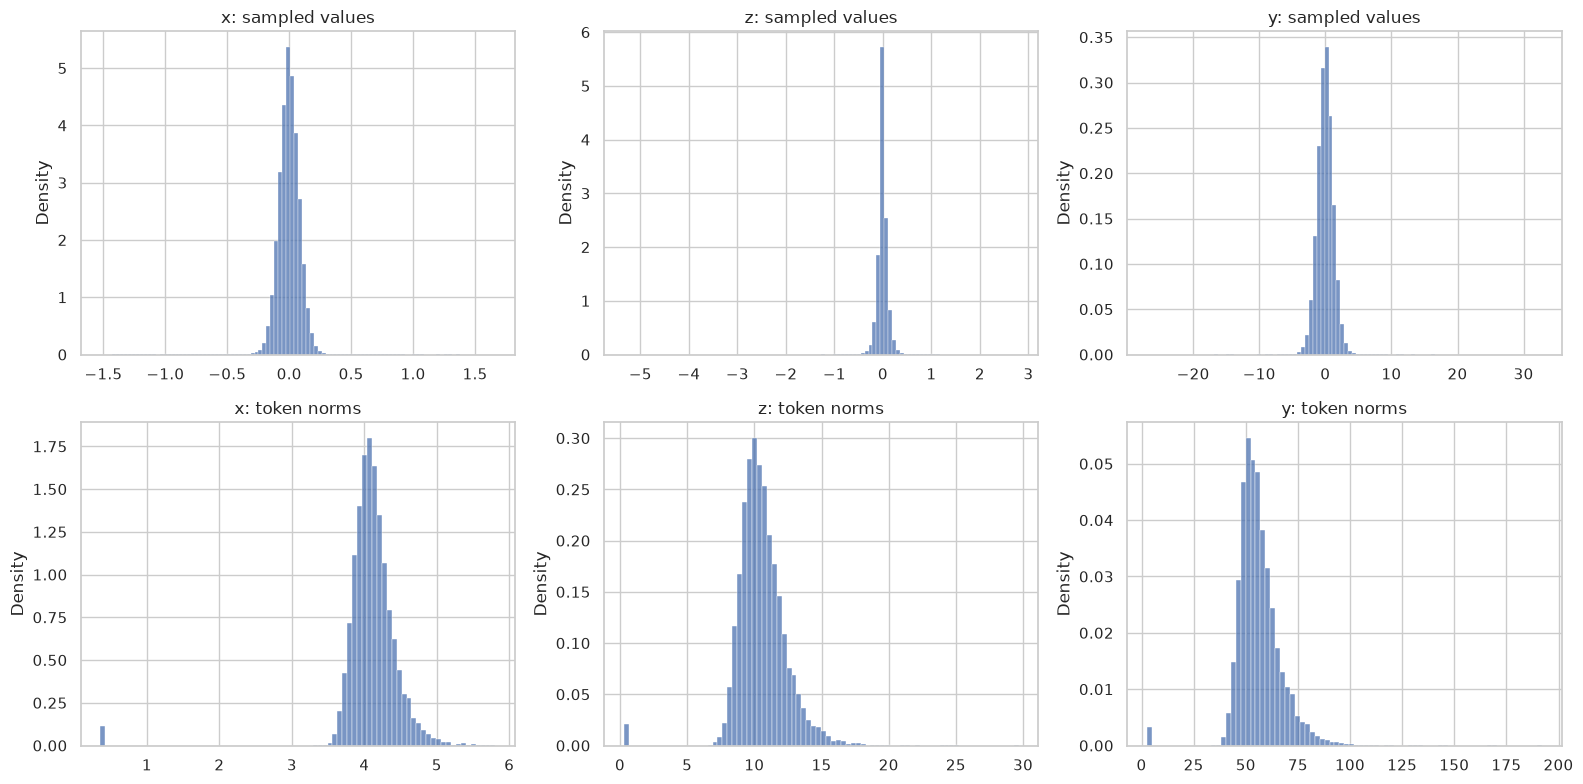

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for column, (name, values) in enumerate(train_activations.items()):
    flat_sample = values.flatten()[::max(1, values.numel() // 100_000)].float().numpy()
    sns.histplot(flat_sample, bins=100, ax=axes[0, column], stat='density')
    axes[0, column].set_title(f'{name}: sampled values')
    norms = values.float().norm(dim=-1)
    sns.histplot(norms.numpy(), bins=80, ax=axes[1, column], stat='density')
    axes[1, column].set_title(f'{name}: token norms')
plt.tight_layout()

## Covariance spectra

The participation-ratio effective rank, stable rank, and variance thresholds are reported together. No single scalar is interpreted as the correct student width. The z eigendecomposition is the expensive cell and is intended for the remote RTX 4090.

In [11]:
decompositions = {}
spectra = {}
for name, values in train_activations.items():
    decomposition = covariance_eigendecomposition(
        values, device=DEVICE, with_eigenvectors=(name == 'z')
    )
    decompositions[name] = decomposition
    spectra[name] = summarize_activation_spectrum(values, decomposition)

spectrum_df = pd.DataFrame([
    {'activation': name, **summary.to_dict(include_eigenvalues=False)}
    for name, summary in spectra.items()
])
spectrum_df

,activation,num_tokens,dimension,effective_rank,normalized_effective_rank,stable_rank,normalized_stable_rank,k90,k95,k99,mean_energy_fraction
0,x,12288,2048,302.764221,0.147834,31.344704,0.015305,1160,1465,1864,0.179169
1,z,12288,8192,1081.038088,0.131963,104.196155,0.012719,3239,4338,6290,0.036574
2,y,12288,2048,124.510496,0.060796,12.175180,0.005945,1075,1361,1784,0.033437


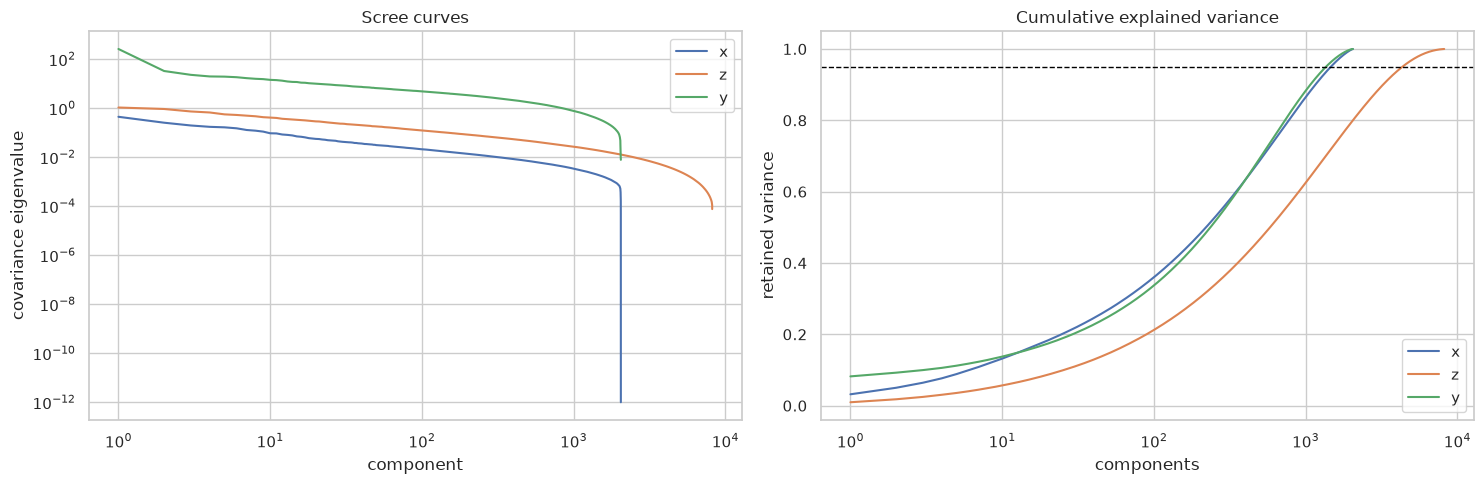

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, summary in spectra.items():
    eigenvalues = summary.eigenvalues
    axes[0].plot(torch.arange(1, eigenvalues.numel() + 1), eigenvalues.clamp_min(1e-12), label=name)
    axes[1].plot(torch.arange(1, eigenvalues.numel() + 1), eigenvalues.cumsum(0) / eigenvalues.sum(), label=name)
axes[0].set(xscale='log', yscale='log', xlabel='component', ylabel='covariance eigenvalue', title='Scree curves')
axes[1].set(xscale='log', xlabel='components', ylabel='retained variance', title='Cumulative explained variance')
axes[1].axhline(0.95, color='black', linestyle='--', linewidth=1)
for axis in axes:
    axis.legend()
plt.tight_layout()

In [13]:
z_decomposition = decompositions['z']
orders = coordinate_orders(train_activations['z'], seed=SEED)
down_weight = down_projection.weight.detach().cpu()
down_bias = down_projection.bias.detach().cpu() if down_projection.bias is not None else None

reconstruction_results = []
reconstruction_results.extend(evaluate_reconstruction(
    validation_activations['z'], z_decomposition.mean, PCA_RANKS,
    method='pca', basis=z_decomposition.eigenvectors,
    output_weight=down_weight, output_bias=down_bias, device=DEVICE,
))
for method, order in orders.items():
    reconstruction_results.extend(evaluate_reconstruction(
        validation_activations['z'], z_decomposition.mean, PCA_RANKS,
        method=method, coordinate_order=order,
        output_weight=down_weight, output_bias=down_bias, device=DEVICE,
    ))
reconstruction_df = pd.DataFrame([asdict(result) for result in reconstruction_results])
reconstruction_df

,method,rank,activation_relative_mse,output_relative_mse
0,pca,64,0.858577,0.808394
1,pca,128,0.817234,0.770956
2,pca,256,0.760326,0.720793
3,pca,512,0.684504,0.649180
4,pca,1024,0.583797,0.548626
5,pca,2048,0.448744,0.411834
6,pca,4096,0.262989,0.232272
7,random_coordinates,64,0.958406,0.960871
8,random_coordinates,128,0.949544,0.952027
9,random_coordinates,256,0.935565,0.935529


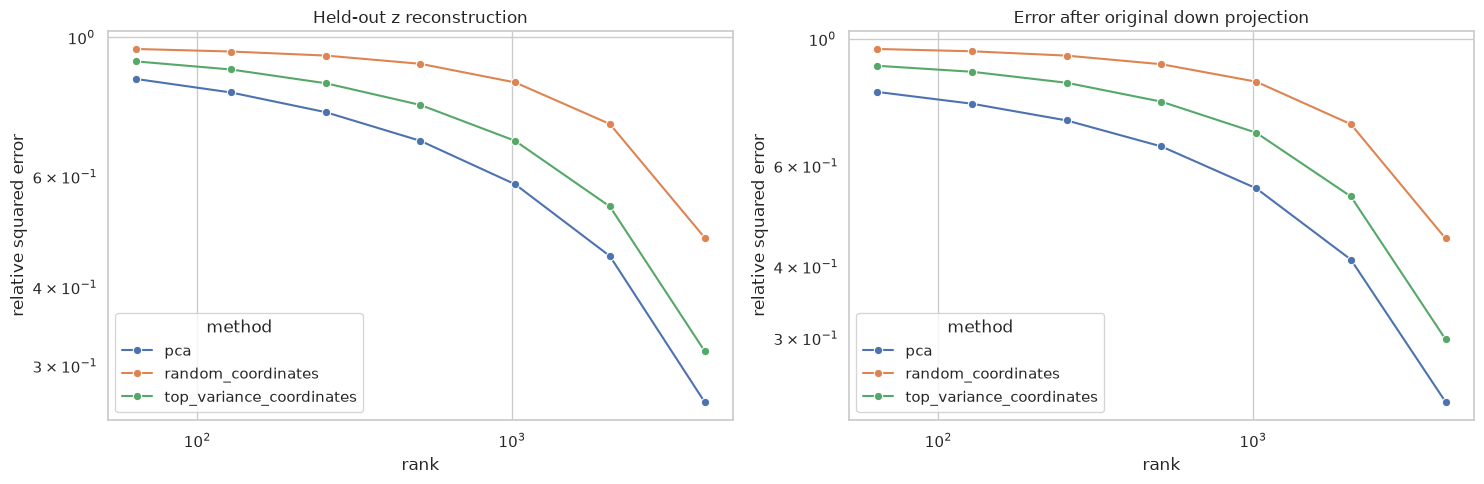

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=reconstruction_df, x='rank', y='activation_relative_mse', hue='method', marker='o', ax=axes[0])
sns.lineplot(data=reconstruction_df, x='rank', y='output_relative_mse', hue='method', marker='o', ax=axes[1])
axes[0].set(xscale='log', yscale='log', title='Held-out z reconstruction', ylabel='relative squared error')
axes[1].set(xscale='log', yscale='log', title='Error after original down projection', ylabel='relative squared error')
plt.tight_layout()

In [15]:
artifact = {
    'schema_version': 1,
    'status': 'exploratory',
    'model': {
        'id': model_config.model_id,
        'resolved_revision': getattr(model.config, '_commit_hash', None),
        'target_layer': TARGET_LAYER,
        'mlp_path': block.path,
        'requested_config': asdict(model_config),
    },
    'data': {
        'sequence_length': data_config.sequence_length,
        'calibration_batches': data_config.num_calibration_batches,
        'validation_batches': data_config.num_operator_validation_batches,
        'seed': SEED,
        'requested_config': asdict(data_config),
    },
    'pca_ranks': list(PCA_RANKS),
    'environment': environment_record(),
    'descriptive': descriptive_df.to_dict(orient='records'),
    'histograms': histogram_data,
    'spectra': {name: summary.to_dict() for name, summary in spectra.items()},
    'reconstruction': reconstruction_df.to_dict(orient='records'),
}
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(json_value(artifact), indent=2, allow_nan=False), encoding='utf-8')
print(f'Saved summary metrics and plot data to {OUTPUT_PATH}')

Saved summary metrics and plot data to /home/sgulas/thesis/development/data/results/notebook-block-study/activation-layer-11.json


## Interpretation checklist

1. Is apparent low rank stable on held-out data?
2. Does PCA preserve y substantially better than coordinate retention?
3. Do low-variance directions become important after down_proj?
4. Which observations are only properties of this layer and calibration distribution?

Do not promote answers from this one-layer notebook into general model claims.